In [1]:
%pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install SQLAlchemy

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install load_dotenv

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install ipython-sql

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


# Set up database

In [8]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# SHOWER LOG

In [9]:
import pandas as pd

query = "SELECT * FROM SHOWER_LOG"
df = pd.read_sql(query, engine)

In [10]:
df.head()

,USER_ID,DAY_ID,SHOWER_START,SHOWER_DURING,SHOWER_TEMP
0,1,1,0 days 15:00:00,long,hot
1,1,2,0 days 13:00:00,long,hot
2,1,3,0 days 08:00:00,long,warm
3,1,3,0 days 20:30:00,short,hot
4,1,4,0 days 13:00:00,long,hot


In [11]:
print(df.describe())

       USER_ID     DAY_ID               SHOWER_START
count     11.0  11.000000                         11
mean       1.0   5.000000  0 days 12:36:49.090909090
std        0.0   2.607681  0 days 05:16:39.866028235
min        1.0   1.000000            0 days 06:15:00
25%        1.0   3.000000            0 days 08:07:30
50%        1.0   5.000000            0 days 13:00:00
75%        1.0   7.000000            0 days 14:15:00
max        1.0   9.000000            0 days 22:00:00


In [12]:
import matplotlib.pyplot as plt

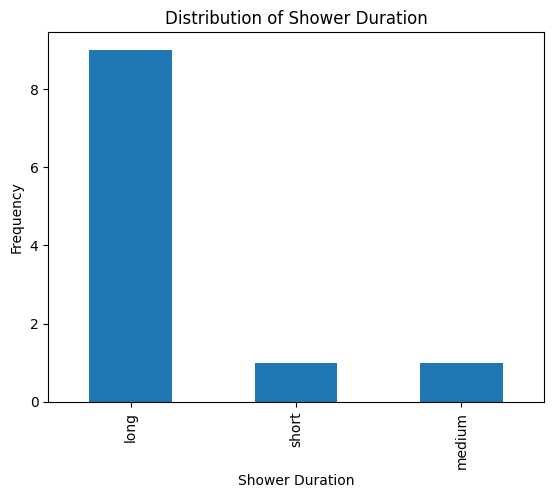

In [13]:
df['SHOWER_DURING'].value_counts().plot(kind='bar')
import matplotlib.pyplot as plt
plt.xlabel("Shower Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Shower Duration")
plt.show()

# PHONE SCREEN

In [14]:
query = "SELECT `DAY`, `SCREEN_TIME`, `SOCIAL` FROM `SAMSUNG_PHONE_SCREEN` NATURAL JOIN `DAY`"
ps = pd.read_sql(query, engine)

In [15]:
ps.head()

,DAY,SCREEN_TIME,SOCIAL
0,2025-06-20,399.0,353.0
1,2025-06-21,226.0,117.0
2,2025-06-22,274.0,195.0
3,2025-06-23,300.0,206.0
4,2025-06-24,123.0,113.0


In [16]:
print(ps[['SCREEN_TIME','SOCIAL']].describe())

       SCREEN_TIME      SOCIAL
count     8.000000    8.000000
mean    254.000000  160.375000
std      86.410978   89.380307
min     123.000000   91.000000
25%     210.250000  108.000000
50%     259.000000  116.000000
75%     300.750000  197.750000
max     399.000000  353.000000


<function matplotlib.pyplot.show(close=None, block=None)>

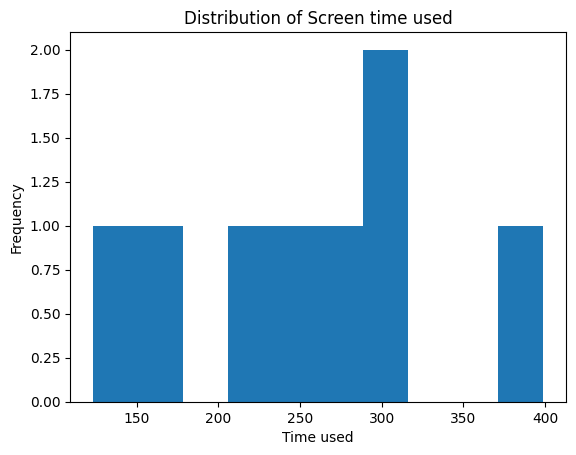

In [17]:
ps['SCREEN_TIME'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Screen time used")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

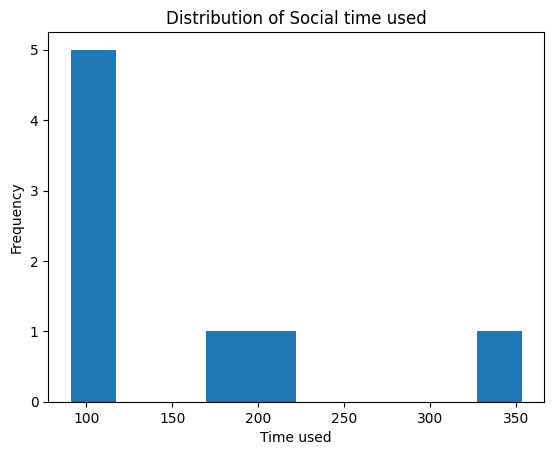

In [23]:
ps['SOCIAL'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Social time used")
plt.show

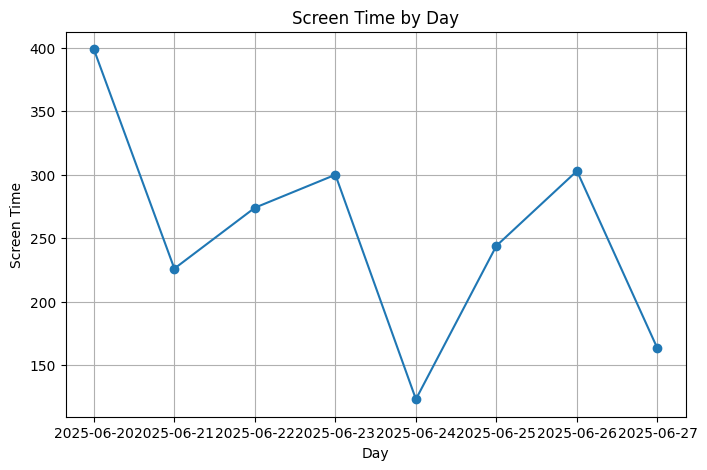

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SCREEN_TIME'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day')
plt.grid(True)
plt.show()

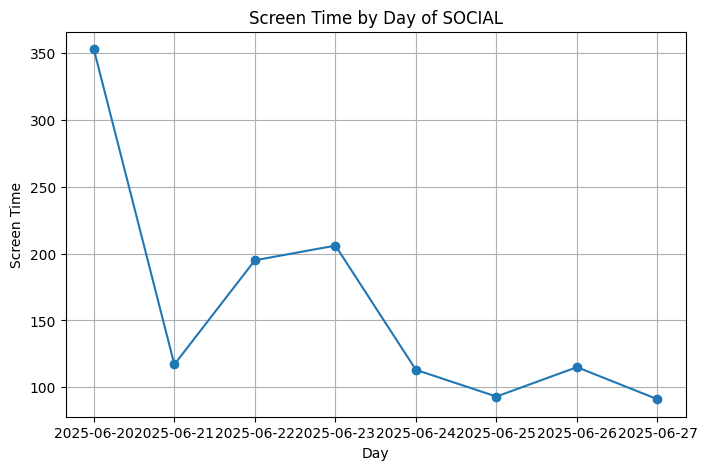

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SOCIAL'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day of SOCIAL')
plt.grid(True)
plt.show()

$z$-score

In [21]:
from scipy.stats import zscore

ps['z_score of SCREEN_TIME'] = zscore(ps['SCREEN_TIME'])
ps['z_score of SOCIAL'] = zscore(ps['SOCIAL'])

ps.head()

,DAY,SCREEN_TIME,SOCIAL,z_score of SCREEN_TIME,z_score of SOCIAL
0,2025-06-20,399.0,353.0,1.793887,2.303917
1,2025-06-21,226.0,117.0,-0.346406,-0.518792
2,2025-06-22,274.0,195.0,0.247433,0.414137
3,2025-06-23,300.0,206.0,0.569095,0.545704
4,2025-06-24,123.0,113.0,-1.620684,-0.566635


Chebyshev's theorem

In [22]:
z = 1.6634959668526281
print(1-(1/(z*z)))

0.6386263390044107


# EATING LOG